In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

Part (a): deterministic graph built.
N = 1024 edges = 6144


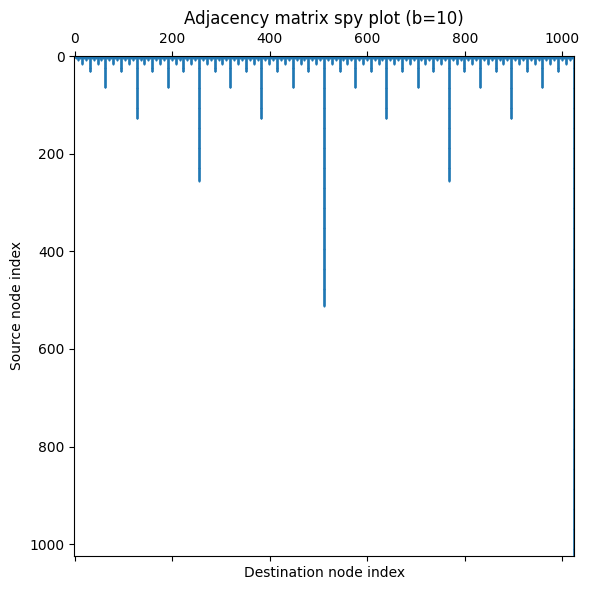

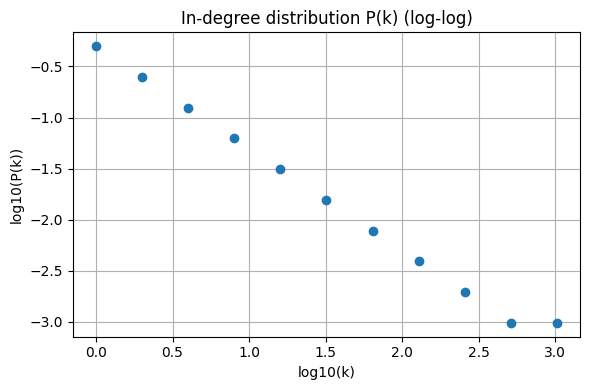

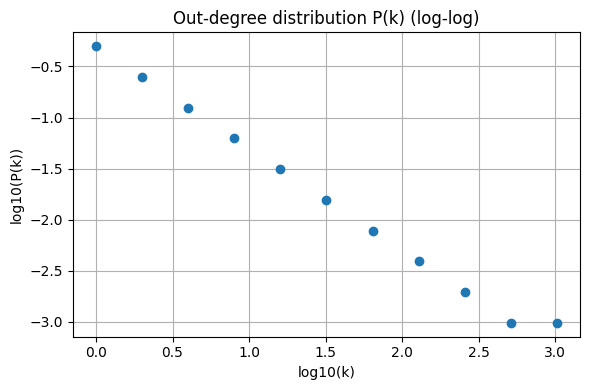


Power-law fit (simple log-log linear fit):
In-degree fit: {'slope_m': -0.9545454545454545, 'intercept_a': -0.34207954052725126, 'gamma': 0.9545454545454545}
Out-degree fit: {'slope_m': -0.9545454545454545, 'intercept_a': -0.34207954052725126, 'gamma': 0.9545454545454545}


In [7]:
def deterministic_scale_free_adjacency(b: int) -> np.ndarray:

    N = 1 << b
    A = np.zeros((N, N), dtype=bool)

    for i in range(b + 1):
        src_count = 1 << (b - i)
        S = np.arange(src_count, dtype=np.int32)

        suffix = (1 << (b - i)) - 1
        X = np.arange(1 << i, dtype=np.int32)
        D = (X << (b - i)) | suffix

        A[np.ix_(S, D)] = True

    return A

def plot_adjacency_spy(A: np.ndarray, title: str = "Adjacency matrix (spy plot)") -> None:
    plt.figure(figsize=(6, 6))
    plt.spy(A, markersize=0.5)
    plt.title(title)
    plt.xlabel("Destination node index")
    plt.ylabel("Source node index")
    plt.tight_layout()
    plt.show()

def degree_distributions_from_adjacency(A: np.ndarray):

    out_deg = A.sum(axis=1).astype(np.int64)
    in_deg = A.sum(axis=0).astype(np.int64)
    return in_deg, out_deg

def plot_degree_distribution_loglog(deg: np.ndarray, title: str):

    deg = np.asarray(deg)
    deg = deg[deg > 0]
    if deg.size == 0:
        print("No positive degrees to plot.")
        return None, None

    k_max = int(deg.max())
    counts = np.bincount(deg, minlength=k_max + 1)
    k_vals = np.arange(len(counts))
    pk = counts / counts.sum()

    mask = (k_vals > 0) & (pk > 0)
    k_vals = k_vals[mask]
    pk = pk[mask]

    plt.figure(figsize=(6, 4))
    plt.plot(np.log10(k_vals), np.log10(pk), marker="o", linestyle="None")
    plt.title(title)
    plt.xlabel("log10(k)")
    plt.ylabel("log10(P(k))")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return k_vals, pk

def fit_power_law_exponent(k_vals: np.ndarray, pk: np.ndarray, k_min: int = 1):

    k_vals = np.asarray(k_vals)
    pk = np.asarray(pk)
    mask = (k_vals >= k_min) & (pk > 0)
    x = np.log10(k_vals[mask])
    y = np.log10(pk[mask])
    if x.size < 2:
        return None

    m, a = np.polyfit(x, y, 1)
    gamma = -m
    return {"slope_m": float(m), "intercept_a": float(a), "gamma": float(gamma)}

b = 10
A_det = deterministic_scale_free_adjacency(b=b)
print("Part (a): deterministic graph built.")
print("N =", A_det.shape[0], "edges =", int(A_det.sum()))

plot_adjacency_spy(A_det, title="Adjacency matrix spy plot (b=10)")

in_deg, out_deg = degree_distributions_from_adjacency(A_det)

k_in, p_in = plot_degree_distribution_loglog(in_deg, title="In-degree distribution P(k) (log-log)")
k_out, p_out = plot_degree_distribution_loglog(out_deg, title="Out-degree distribution P(k) (log-log)")

fit_in = fit_power_law_exponent(k_in, p_in, k_min=1) if k_in is not None else None
fit_out = fit_power_law_exponent(k_out, p_out, k_min=1) if k_out is not None else None

print("\nPower-law fit (simple log-log linear fit):")
print("In-degree fit:", fit_in)
print("Out-degree fit:", fit_out)


In [5]:
def sample_pattern(b: int, x: int, rng: random.Random):

    positions = list(range(b))
    wild_pos = rng.sample(positions, x)
    wild_set = set(wild_pos)

    fixed_mask = 0
    fixed_value = 0
    for pos in range(b):
        bit_index = b - 1 - pos
        if pos in wild_set:
            continue
        fixed_mask |= (1 << bit_index)
        if rng.random() < 0.5:
            fixed_value |= (1 << bit_index)

    return wild_pos, fixed_mask, fixed_value

def matching_nodes(b: int, wild_pos, fixed_mask: int, fixed_value: int) -> np.ndarray:

    x = len(wild_pos)
    N = 1 << b
    out = np.empty(1 << x, dtype=np.int32)

    wild_bit_indices = [(b - 1 - pos) for pos in wild_pos]

    base = fixed_value

    for t in range(1 << x):
        v = base
        for j, bit_idx in enumerate(wild_bit_indices):
            if (t >> j) & 1:
                v |= (1 << bit_idx)
            else:
                v &= ~(1 << bit_idx)
        out[t] = v

    return out

def rg_density(b: int, x: int, r: int, seed: int = 0) -> float:

    rng = random.Random(seed)
    N = 1 << b
    A = np.zeros((N, N), dtype=bool)

    for _ in range(r):
        S_wild, S_mask, S_val = sample_pattern(b, x, rng)
        D_wild, D_mask, D_val = sample_pattern(b, x, rng)

        S_nodes = matching_nodes(b, S_wild, S_mask, S_val)
        D_nodes = matching_nodes(b, D_wild, D_mask, D_val)

        A[np.ix_(S_nodes, D_nodes)] = True

    density = A.mean()
    return float(density)

def theoretical_density(b: int, x: int, r: int) -> float:

    pi = 2 ** (x - b)
    rho = 1.0 - (1.0 - pi * pi) ** (2 * r)
    return float(rho)


RG sweep r values: [2, 3, 5, 9, 14, 23, 37, 60, 98, 160]


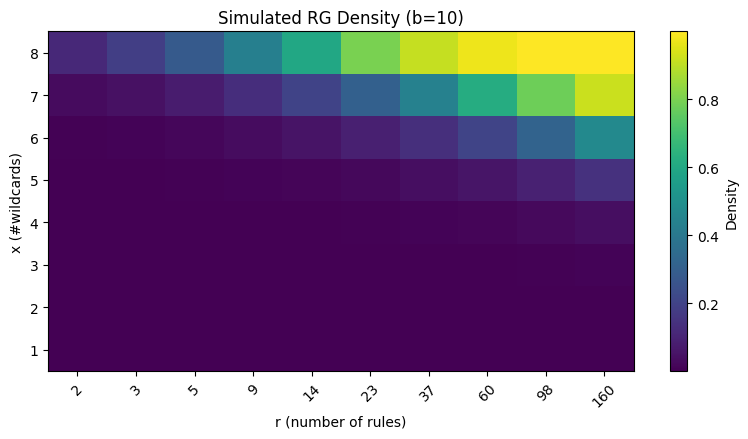

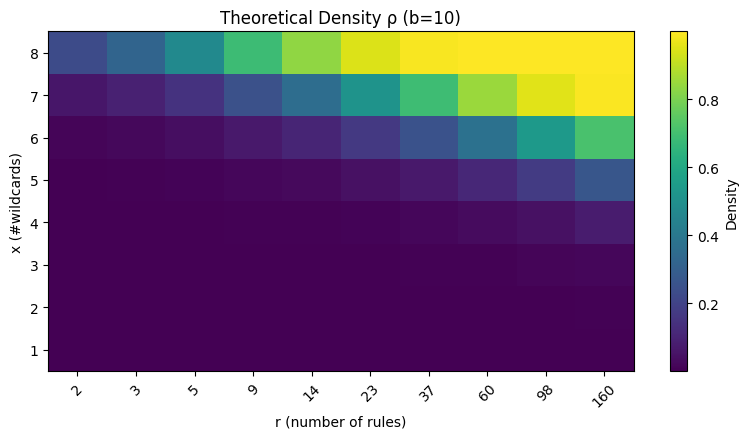

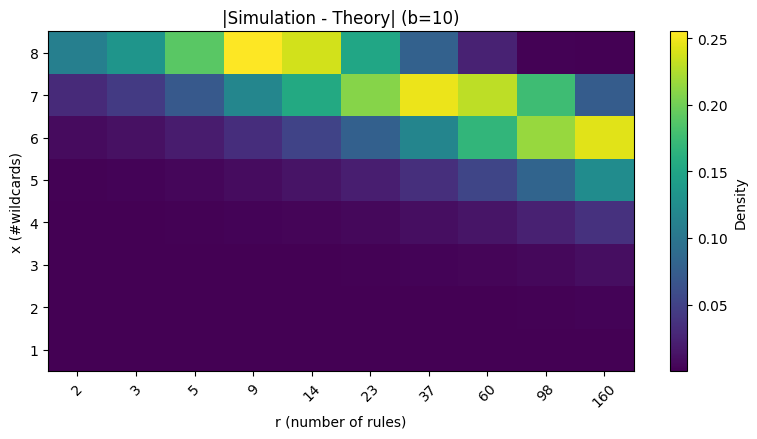

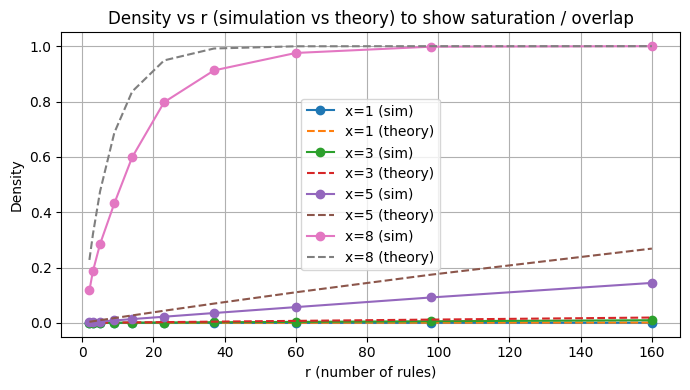


Done. You now have all figures for Q2(a) and Q2(b).


In [8]:
b_rg = 10

x_values = list(range(1, 9))  # x = 1..8
r_values = np.unique(np.round(np.logspace(np.log10(2), np.log10(160), num=10)).astype(int))
r_values = [int(v) for v in r_values]
print("\nRG sweep r values:", r_values)

dens_sim = np.zeros((len(x_values), len(r_values)), dtype=float)
dens_th  = np.zeros((len(x_values), len(r_values)), dtype=float)

for i, x in enumerate(x_values):
    for j, r in enumerate(r_values):
        dens_sim[i, j] = rg_density(b=b_rg, x=x, r=r, seed=SEED + 1000*x + 10*r)
        dens_th[i, j]  = theoretical_density(b=b_rg, x=x, r=r)

def plot_heatmap(Z, x_values, r_values, title, cmap=None):
    plt.figure(figsize=(8, 4.5))
    plt.imshow(Z, aspect="auto", origin="lower", cmap=cmap)
    plt.colorbar(label="Density")
    plt.xticks(range(len(r_values)), r_values, rotation=45)
    plt.yticks(range(len(x_values)), x_values)
    plt.xlabel("r (number of rules)")
    plt.ylabel("x (#wildcards)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_heatmap(dens_sim, x_values, r_values, title="Simulated RG Density (b=10)")
plot_heatmap(dens_th,  x_values, r_values, title="Theoretical Density ρ (b=10)")
plot_heatmap(np.abs(dens_sim - dens_th), x_values, r_values, title="|Simulation - Theory| (b=10)", cmap=None)

plt.figure(figsize=(7, 4))
for x in [1, 3, 5, 8]:
    idx = x_values.index(x)
    plt.plot(r_values, dens_sim[idx], marker="o", label=f"x={x} (sim)")
    plt.plot(r_values, dens_th[idx], linestyle="--", label=f"x={x} (theory)")
plt.xlabel("r (number of rules)")
plt.ylabel("Density")
plt.title("Density vs r (simulation vs theory) to show saturation / overlap")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("\nDone. You now have all figures for Q2(a) and Q2(b).")